# 1.3 — Integral y lema de Itô

## Motivación

En 01.2 vimos el hecho que rompe el cálculo clásico: el movimiento browniano tiene variación cuadrática finita y determinista, $[W]_T=T$, pero variación total infinita. Eso significa que $dW_t$ no puede tratarse como un diferencial de Riemann-Stieltjes ordinario — la integral $\int_0^T \theta_t\, dW_t$, que necesitamos para escribir "cuánto dinero gana una estrategia de trading $\theta_t$ contra un activo que sigue $W_t$", requiere una definición nueva. Ese es el primer objeto de este notebook: la **integral de Itô**, construida como límite de sumas de Riemann-Itô donde el integrando se evalúa en el extremo **izquierdo** de cada subintervalo — la elección "no anticipante" que corresponde a una estrategia de trading real (hoy no puedo usar el precio de mañana para decidir mi posición de hoy) y que, como veremos, es exactamente la que hace de la integral una martingala.

El segundo objeto es el **lema de Itô**: la regla de la cadena del cálculo estocástico. Como $(dW_t)^2=dt$ no es despreciable frente a $dt$ (a diferencia del cálculo clásico, donde $(dx)^2$ sí lo es), diferenciar una función de un proceso de Itô produce un término extra de segundo orden. Este único resultado es el motor de casi todo lo que sigue en el currículum: en 01.4 lo usamos para escribir las soluciones exactas de SDEs (GBM, Ornstein-Uhlenbeck); en 01.5, para derivar Girsanov; y en 03.1, para obtener la ecuación de Black-Scholes por réplica.

Cubrimos: (i) la construcción de la integral de Itô para procesos simples vía sumas de punto izquierdo, y por qué el punto de evaluación importa — comparación explícita con la convención de Stratonovich (punto medio); (ii) la isometría de Itô (derivación) y la propiedad de martingala; (iii) el lema de Itô — derivación heurística vía expansión de Taylor y la regla $(dW_t)^2=dt$, la versión con deriva (proceso de Itô general), y tres ejemplos trabajados: $d(W_t^2)$, $d(\ln S_t)$ para GBM, y $d(e^{W_t-t/2})$.

## 1. La integral de Itô para procesos simples

### 1.1 Procesos simples y la suma de Itô (punto izquierdo)

Sea $\Pi=\{0=t_0<t_1<\dots<t_n=T\}$ una partición de $[0,T]$. Un **proceso simple** es un proceso de la forma
$$
\theta_t = \theta_i, \qquad t\in[t_i,t_{i+1}), \qquad i=0,\dots,n-1,
$$
donde cada $\theta_i$ es una variable aleatoria $\mathcal{F}_{t_i}$-medible (es decir, conocida con la información disponible en $t_i$ — **no anticipante**). Piénsese en $\theta_i$ como el tamaño de una posición fijada al inicio del subintervalo $[t_i,t_{i+1})$ y mantenida constante hasta $t_{i+1}$.

**Definición (integral de Itô de un proceso simple).**
$$
I(\theta) := \int_0^T \theta_t\, dW_t := \sum_{i=0}^{n-1} \theta_i\,\left(W_{t_{i+1}}-W_{t_i}\right) = \sum_{i=0}^{n-1}\theta_i\,\Delta W_i.
$$
La elección del **extremo izquierdo** $\theta_i$ (evaluado en $t_i$, no en $t_{i+1}$ ni en el punto medio) no es cosmética: es la que codifica que $\theta$ no puede usar información del futuro dentro del subintervalo. Para un proceso general (adaptado, con $\mathbb{E}\left[\int_0^T\theta_t^2\,dt\right]<\infty$), $\int_0^T\theta_t\,dW_t$ se define como el límite en $L^2$ de sumas de Itô de procesos simples que aproximan a $\theta$ cuando $\|\Pi\|\to0$ — no demostramos la existencia de este límite (ver Shreve II §4.3, Øksendal §3.1), pero la isometría de la sección 2.1 es precisamente la herramienta que garantiza que las aproximaciones son de Cauchy en $L^2$.

### 1.2 ¿Por qué importa el punto de evaluación? Itô vs Stratonovich

En el cálculo de Riemann-Stieltjes clásico, si $g$ tiene variación acotada, el límite de $\sum f(\xi_i)(g(t_{i+1})-g(t_i))$ no depende de dónde, dentro de $[t_i,t_{i+1}]$, se escoja el punto de evaluación $\xi_i$ — la variación acotada de $g$ fuerza a que la diferencia entre evaluar en un extremo u otro sea $o(1)$ en la suma. Con $W_t$ esto **falla**: $W$ tiene variación cuadrática no nula, así que la diferencia entre $W_{t_i}$ y $W_{\xi_i}$ dentro del mismo subintervalo está correlacionada con el propio incremento $\Delta W_i$, y esa correlación no se anula en el límite. El punto de evaluación deja de ser un detalle técnico y se vuelve parte de la definición.

Tomemos el ejemplo canónico $\theta_t = W_t$, es decir $\int_0^T W_t\,dW_t$, con partición uniforme $\delta_i = t_{i+1}-t_i$.

**Suma de Itô (punto izquierdo).** Usando la identidad algebraica $a(b-a) = \tfrac12(b^2-a^2) - \tfrac12(b-a)^2$ con $a=W_{t_i}$, $b=W_{t_{i+1}}$:
$$
\sum_{i=0}^{n-1} W_{t_i}\,\Delta W_i = \sum_{i=0}^{n-1}\left[\frac{W_{t_{i+1}}^2-W_{t_i}^2}{2} - \frac{(\Delta W_i)^2}{2}\right] = \frac{W_T^2 - W_0^2}{2} - \frac{Q_n}{2} = \frac{W_T^2}{2} - \frac{Q_n}{2},
$$
donde $Q_n=\sum_i(\Delta W_i)^2$ es la variación cuadrática de la partición (01.2, §2.3). Esta igualdad es **exacta para cualquier $n$** — es puramente algebraica, no un límite. Como $Q_n\xrightarrow{L^2}T$ cuando $\|\Pi\|\to0$ (01.2), se sigue que
$$
\int_0^T W_t\,dW_t = \frac{W_T^2-T}{2}.
$$
El término $-T/2$ —ausente en la regla clásica $\int x\,dx = x^2/2$— es la primera aparición del "término de Itô" que generalizaremos en la sección 3.

**Suma de punto medio (Stratonovich).** Sea $m_i=(t_i+t_{i+1})/2$, y descompongamos el incremento en sus dos mitades: $a_i := W_{m_i}-W_{t_i}$ y $b_i := W_{t_{i+1}}-W_{m_i}$, de modo que $\Delta W_i = a_i+b_i$ y, por incrementos independientes de $W$, $a_i,b_i$ son independientes con $a_i,b_i\sim\mathcal{N}(0,\delta_i/2)$. Entonces
$$
W_{m_i}\,\Delta W_i = (W_{t_i}+a_i)(a_i+b_i) = W_{t_i}\,\Delta W_i + a_i^2 + a_i b_i,
$$
y sumando sobre $i$:
$$
\sum_{i=0}^{n-1} W_{m_i}\,\Delta W_i = \underbrace{\sum_i W_{t_i}\Delta W_i}_{\to (W_T^2-T)/2} + \underbrace{\sum_i a_i^2}_{\mathbb{E}[\cdot]=T/2} + \underbrace{\sum_i a_i b_i}_{\mathbb{E}[\cdot]=0,\ \to 0 \text{ en } L^2}.
$$
Los dos términos nuevos: $\mathbb{E}[\sum a_i^2]=\sum \delta_i/2 = T/2$ con $\text{Var}(\sum a_i^2)=\sum 2(\delta_i/2)^2=O(\|\Pi\|)\to0$; y $\sum a_ib_i$ tiene media $0$ y $\text{Var}(\sum a_ib_i)=\sum\text{Var}(a_i)\text{Var}(b_i)=\sum(\delta_i/2)^2=O(\|\Pi\|)\to0$ (por independencia de $a_i,b_i$ entre subintervalos y dentro de cada uno). Así,
$$
\sum_{i=0}^{n-1}W_{m_i}\,\Delta W_i \xrightarrow{L^2} \frac{W_T^2-T}{2}+\frac{T}{2} = \frac{W_T^2}{2} =: \left(\text{S}\right)\!\!\int_0^T W_t\circ dW_t.
$$
La integral de **Stratonovich** (notación $\circ dW_t$) sí obedece la regla clásica $\int x\,dx=x^2/2$ — es la que aparece naturalmente como límite de aproximaciones "suaves" de ruido blanco en física — pero **no** es una martingala (§2.2) y no es la convención usada en finanzas: una estrategia de trading que necesitara conocer $W_{m_i}$ (información de "medio paso en el futuro") para decidir su posición en $t_i$ sería anticipante, y por lo tanto no implementable. Por eso el cálculo de Itô (punto izquierdo) es el estándar en pricing, y la demo 1 reproduce numéricamente ambas sumas y su diferencia $T/2$.

## 2. Isometría de Itô y martingalidad

### 2.1 Isometría de Itô (derivación)

**Proposición (isometría de Itô).** Para $\theta$ simple, adaptado, con $\mathbb{E}[\theta_i^2]<\infty$ para cada $i$,
$$
\mathbb{E}\left[\left(\int_0^T \theta_t\,dW_t\right)^2\right] = \int_0^T \mathbb{E}[\theta_t^2]\,dt.
$$

*Demostración.* Escribimos $I(\theta)=\sum_i \theta_i\Delta W_i$ y expandimos el cuadrado:
$$
I(\theta)^2 = \sum_{i=0}^{n-1}\theta_i^2(\Delta W_i)^2 + \sum_{i\neq j}\theta_i\theta_j\,\Delta W_i\,\Delta W_j.
$$
**Términos cruzados ($i<j$, el caso $i>j$ es simétrico).** $\theta_i\theta_j\Delta W_i$ es $\mathcal{F}_{t_j}$-medible (depende solo de información hasta $t_j$), y $\Delta W_j=W_{t_{j+1}}-W_{t_j}$ es independiente de $\mathcal{F}_{t_j}$ con $\mathbb{E}[\Delta W_j]=0$. Por la torre de la esperanza,
$$
\mathbb{E}[\theta_i\theta_j\Delta W_i\Delta W_j] = \mathbb{E}\big[\theta_i\theta_j\Delta W_i\,\mathbb{E}[\Delta W_j\mid\mathcal{F}_{t_j}]\big] = \mathbb{E}[\theta_i\theta_j\Delta W_i\cdot 0] = 0.
$$
**Términos diagonales.** $\theta_i^2$ es $\mathcal{F}_{t_i}$-medible y $(\Delta W_i)^2$ es independiente de $\mathcal{F}_{t_i}$ con $\mathbb{E}[(\Delta W_i)^2]=\delta_i=t_{i+1}-t_i$, así que
$$
\mathbb{E}[\theta_i^2(\Delta W_i)^2] = \mathbb{E}\big[\theta_i^2\,\mathbb{E}[(\Delta W_i)^2\mid\mathcal{F}_{t_i}]\big] = \mathbb{E}[\theta_i^2]\,\delta_i.
$$
Sumando,
$$
\mathbb{E}[I(\theta)^2] = \sum_{i=0}^{n-1}\mathbb{E}[\theta_i^2]\,\delta_i = \int_0^T \mathbb{E}[\theta_t^2]\,dt. \qquad \blacksquare
$$

La isometría es exactamente lo que se necesita para (i) extender la definición de $\theta$ simple a $\theta$ general por un argumento de aproximación en $L^2$ (procesos simples son densos en el espacio $L^2([0,T]\times\Omega)$ de integrandos adaptados), y (ii) calcular momentos de segundo orden de integrales de Itô sin conocer su distribución completa — la demo 2 la verifica numéricamente para $\theta_t=W_t$.

### 2.2 Martingalidad de la integral de Itô

**Proposición.** El proceso $M_t := \int_0^t \theta_s\,dW_s$ (con $\theta$ adaptado, $\mathbb{E}[\int_0^T\theta_s^2\,ds]<\infty$) es una $\mathcal{F}_t$-martingala.

*Bosquejo.* Para $\theta$ simple y $s=t_k<t=t_l$ ambos puntos de la partición, $M_t-M_s=\sum_{i=k}^{l-1}\theta_i\Delta W_i$. Cada término tiene $\mathbb{E}[\theta_i\Delta W_i\mid\mathcal{F}_{t_i}]=\theta_i\,\mathbb{E}[\Delta W_i\mid\mathcal{F}_{t_i}]=\theta_i\cdot 0=0$ (mismo argumento de independencia que en la isometría), así que por la torre de la esperanza $\mathbb{E}[M_t-M_s\mid\mathcal{F}_s]=0$, es decir $\mathbb{E}[M_t\mid\mathcal{F}_s]=M_s$. Para $\theta$ general se extiende por el límite en $L^2$ que define la integral (Shreve II, Teorema 4.3.1). $\blacksquare$

Esta es la razón estructural por la que el punto de evaluación de la sección 1.2 importa tanto: **solo** la convención de punto izquierdo produce una martingala (el incremento $\theta_i\Delta W_i$ tiene esperanza condicional nula dado el pasado). La suma de Stratonovich, al usar $W_{m_i}$ —información "a medio camino" del futuro del subintervalo—, rompe esa propiedad: de hecho vimos que $\int_0^T W_t\circ dW_t = W_T^2/2$ tiene $\mathbb{E}[W_T^2/2]=T/2\neq0$, mientras que la integral de Itô $\int_0^T W_t\,dW_t=(W_T^2-T)/2$ sí tiene media $0$, consistente con ser una martingala que arranca en $M_0=0$.

## 3. El lema de Itô

### 3.1 Derivación heurística (Taylor + $(dW_t)^2=dt$)

Sea $f(t,x)$ de clase $C^{1,2}$ (una vez diferenciable en $t$, dos veces en $x$) y $W_t$ un movimiento browniano estándar. Expandimos $f(t+dt, W_t+dW_t)$ en Taylor a segundo orden alrededor de $(t,W_t)$:
$$
df = f_t\,dt + f_x\,dW_t + \frac{1}{2}f_{xx}\,(dW_t)^2 + \frac{1}{2}f_{tt}\,(dt)^2 + f_{tx}\,dt\,dW_t + \dots
$$
El paso heurístico central del cálculo de Itô es la **tabla de multiplicación estocástica**, que resume la variación cuadrática de 01.2 (§2.3) y su generalización cruzada:
$$
(dW_t)^2 = dt, \qquad dt\cdot dW_t = 0, \qquad (dt)^2 = 0.
$$
La primera igualdad es la reformulación diferencial de $[W]_T=T$: en una partición fina, $\sum(\Delta W_i)^2\approx\sum\delta_i=\Delta t$ con error que se anula en $L^2$ (01.2, Proposición 2.3). Las otras dos son órdenes superiores: $dt\,dW_t$ tiene "tamaño" $dt\cdot\sqrt{dt}=dt^{3/2}$, y $(dt)^2$ es $dt^2$ — ambos despreciables frente a $dt$ cuando $dt\to0$. Sustituyendo en la expansión y descartando los términos de orden superior a $dt$:
$$
\boxed{df = \left(f_t + \frac{1}{2}f_{xx}\right)dt + f_x\,dW_t.}
$$
Este es el **lema de Itô** para $f(t,W_t)$: comparado con la regla clásica $df=f_x\,dW_t$ (que sería correcta si $W$ fuera diferenciable), aparece el término extra $\tfrac12 f_{xx}\,dt$ — exactamente la contribución de que $(dW_t)^2$ no se pueda despreciar. Esta derivación es heurística (no es una prueba rigurosa: el argumento riguroso parte de la fórmula de Itô para procesos simples §1 y pasa al límite usando la isometría, ver Shreve II Teorema 4.4.1 u Øksendal Teorema 4.1.2), pero el resultado es exacto y es la forma en que se usa en la práctica.

### 3.2 Versión con deriva: proceso de Itô general

Sea $X_t$ un **proceso de Itô**, $dX_t = \mu_t\,dt + \sigma_t\,dW_t$ (con $\mu_t,\sigma_t$ adaptados). La misma tabla de multiplicación da $(dX_t)^2 = \sigma_t^2(dW_t)^2 + 2\mu_t\sigma_t\,dt\,dW_t + \mu_t^2(dt)^2 = \sigma_t^2\,dt$ (los términos con $\mu$ son de orden superior). Para $f(t,x)\in C^{1,2}$, la expansión de Taylor de $f(t+dt,X_t+dX_t)$ con la misma sustitución da:
$$
\boxed{df(t,X_t) = \left(f_t + \mu_t f_x + \frac{1}{2}\sigma_t^2 f_{xx}\right)dt + \sigma_t f_x\,dW_t.}
$$
Esta es la forma general que usaremos repetidamente: 01.4 la aplica para obtener las soluciones exactas de GBM y OU; 01.5 y 03.1 la aplican para derivar Girsanov y Black-Scholes. Nótese que $f(t,W_t)$ de la sección 3.1 es el caso particular $\mu_t=0,\ \sigma_t=1$.

### 3.3 Ejemplos trabajados

**Ejemplo 1: $d(W_t^2)$.** Tomamos $f(x)=x^2$ (sin dependencia en $t$), $X_t=W_t$: $f_x=2x$, $f_{xx}=2$, $f_t=0$. Sustituyendo en 3.1,
$$
d(W_t^2) = \frac{1}{2}\cdot 2\,dt + 2W_t\,dW_t = dt + 2W_t\,dW_t.
$$
Integrando de $0$ a $T$ (con $W_0=0$): $W_T^2 = T + 2\int_0^T W_t\,dW_t$, es decir $\int_0^T W_t\,dW_t = (W_T^2-T)/2$ — recuperamos exactamente el resultado de la sección 1.2, ahora como caso particular del lema de Itô en vez de por cómputo directo de sumas.

**Ejemplo 2: $d(\ln S_t)$ para GBM.** Sea $S_t$ el movimiento browniano geométrico $dS_t=\mu S_t\,dt+\sigma S_t\,dW_t$ (aquí $\mu_t=\mu S_t$, $\sigma_t=\sigma S_t$ en la notación de 3.2). Con $f(x)=\ln x$: $f_x=1/x$, $f_{xx}=-1/x^2$, $f_t=0$. Sustituyendo,
$$
d(\ln S_t) = \left(\mu S_t\cdot\frac{1}{S_t} - \frac{1}{2}\sigma^2S_t^2\cdot\frac{1}{S_t^2}\right)dt + \sigma S_t\cdot\frac{1}{S_t}\,dW_t = \left(\mu-\frac{\sigma^2}{2}\right)dt + \sigma\,dW_t.
$$
Integrando: $\ln S_T = \ln S_0 + \left(\mu-\tfrac{\sigma^2}{2}\right)T + \sigma W_T$, es decir
$$
S_T = S_0\exp\!\left[\left(\mu-\frac{\sigma^2}{2}\right)T + \sigma W_T\right],
$$
la solución exacta de GBM (rederivada con detalle en 01.4). El término $-\sigma^2T/2$ —la "corrección de Itô"— es la razón por la que $\mathbb{E}[S_T]=S_0e^{\mu T}$ (crecimiento esperado a tasa $\mu$) pero $\mathbb{E}[\ln S_T] = \ln S_0+(\mu-\sigma^2/2)T$ (la mediana/tasa de crecimiento logarítmico es menor): sin él, un trader que confundiera "rendimiento esperado" con "tasa de crecimiento logarítmico esperado" sobrestimaría el segundo por $\sigma^2/2$.

**Ejemplo 3: $d(e^{W_t-t/2})$.** Sea $f(t,x)=e^{x-t/2}$, $X_t=W_t$. Entonces $f_t=-\tfrac12 f$, $f_x=f$, $f_{xx}=f$. Sustituyendo en 3.1,
$$
d\!\left(e^{W_t-t/2}\right) = \left(-\frac{1}{2}f + \frac{1}{2}\cdot f\right)dt + f\,dW_t = 0\cdot dt + e^{W_t-t/2}\,dW_t.
$$
El término de deriva se cancela exactamente: $M_t:=e^{W_t-t/2}$ no tiene término $dt$, así que $dM_t=M_t\,dW_t$ es una integral de Itô pura y por lo tanto (§2.2) una **martingala** — la martingala exponencial, que reaparece en 01.5 como la derivada de Radon-Nikodym del cambio de medida de Girsanov y en la fórmula de Black-Scholes como el factor de descuento bajo la medida neutral al riesgo. La cancelación exacta de la deriva (el $-1/2$ en el exponente compensa precisamente el término $\tfrac12 f_{xx}$ del lema de Itô) no es casualidad: es la construcción estándar para "quitarle la deriva" a un GBM y convertirlo en martingala.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 4. Demos

### Demo 1 — $\int_0^T W_t\,dW_t$: sumas de Itô (punto izquierdo) vs Stratonovich (punto medio), convergencia al refinar la partición

Simulamos una única trayectoria de BM muy fina ($N_{\text{fine}}=2^{16}$ pasos en $[0,T=1]$, la misma técnica que en 01.2 §2.3) y la sub-muestreamos en particiones $\Pi_k$ con $n_k=2^k$ puntos, $k=1,\dots,14$. Para cada partición calculamos la suma de Itô (punto izquierdo) y la suma de Stratonovich (punto medio, usando los valores exactos de la trayectoria fina en el punto medio de cada subintervalo) y las comparamos contra $(W_T^2-T)/2$ y $W_T^2/2$ respectivamente.

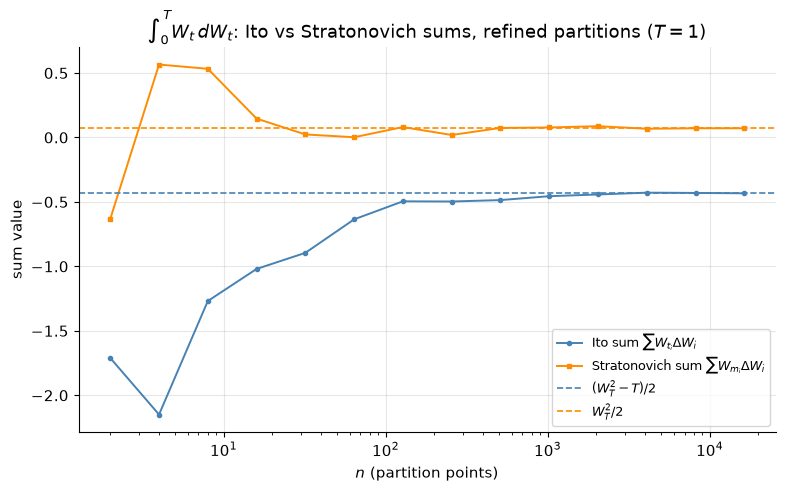

W_T = -0.377735
finest n = 16,384
Ito sum (finest)         = -0.433099   target (W_T^2-T)/2 = -0.428658
Stratonovich sum (finest)= 0.071157   target W_T^2/2     = 0.071342
Q_n (finest)              = 1.008882   target T           = 1.0
Ito sum == (W_T^2-Q_n)/2 exactly (algebraic identity): True


In [2]:
# Demo 1: Ito (left-point) vs Stratonovich (midpoint) sums for int W dW, refined partitions of one BM path
T = 1.0
N_fine = 2**16  # finest resolution: 65,536 steps
dt_fine = T / N_fine

increments_fine = rng.standard_normal(N_fine) * np.sqrt(dt_fine)
W_fine = np.concatenate([[0.0], np.cumsum(increments_fine)])
W_T = W_fine[-1]

k_values = np.arange(1, 15)  # n_k = 2^1 ... 2^14
n_values = 2**k_values

ito_sums = np.empty_like(n_values, dtype=float)
strat_sums = np.empty_like(n_values, dtype=float)
qv_values = np.empty_like(n_values, dtype=float)

for idx, n_k in enumerate(n_values):
    stride = N_fine // n_k
    left_idx = np.arange(n_k) * stride
    right_idx = left_idx + stride
    mid_idx = left_idx + stride // 2

    W_left = W_fine[left_idx]
    W_right = W_fine[right_idx]
    W_mid = W_fine[mid_idx]
    dW = W_right - W_left

    ito_sums[idx] = np.sum(W_left * dW)
    strat_sums[idx] = np.sum(W_mid * dW)
    qv_values[idx] = np.sum(dW**2)

ito_target = (W_T**2 - T) / 2
strat_target = W_T**2 / 2

fig, ax = plt.subplots()
ax.semilogx(n_values, ito_sums, marker="o", markersize=3, color="steelblue", label=r"Ito sum $\sum W_{t_i}\Delta W_i$")
ax.semilogx(n_values, strat_sums, marker="s", markersize=3, color="darkorange", label=r"Stratonovich sum $\sum W_{m_i}\Delta W_i$")
ax.axhline(ito_target, color="steelblue", linestyle="--", linewidth=1.2, label=r"$(W_T^2-T)/2$")
ax.axhline(strat_target, color="darkorange", linestyle="--", linewidth=1.2, label=r"$W_T^2/2$")
ax.set_xlabel("$n$ (partition points)")
ax.set_ylabel("sum value")
ax.set_title(r"$\int_0^T W_t\,dW_t$: Ito vs Stratonovich sums, refined partitions ($T=1$)")
ax.legend(fontsize=9)
plt.show()

print(f"W_T = {W_T:.6f}")
print(f"finest n = {n_values[-1]:,}")
print(f"Ito sum (finest)         = {ito_sums[-1]:.6f}   target (W_T^2-T)/2 = {ito_target:.6f}")
print(f"Stratonovich sum (finest)= {strat_sums[-1]:.6f}   target W_T^2/2     = {strat_target:.6f}")
print(f"Q_n (finest)              = {qv_values[-1]:.6f}   target T           = {T}")
print(f"Ito sum == (W_T^2-Q_n)/2 exactly (algebraic identity): {np.allclose(ito_sums[-1], (W_T**2 - qv_values[-1]) / 2)}")

La suma de Itô (azul) converge a $(W_T^2-T)/2$ y la suma de Stratonovich (naranja) converge a $W_T^2/2$ — ambas curvas se estabilizan conforme $n$ crece, pero hacia límites distintos separados exactamente por $T/2=0.5$, como predice la derivación de §1.2. La igualdad algebraica $\text{suma de Itô}=(W_T^2-Q_n)/2$ se verifica exactamente (no solo en el límite) para cualquier partición: es la identidad de telescopio, y por eso el "error" de la suma de Itô respecto a su límite es literalmente $(T-Q_n)/2$ — la misma cantidad cuya convergencia a $0$ ya se demostró en 01.2 §2.3. La suma de Stratonovich converge al mismo tipo de límite pero con un residuo adicional ($\sum a_i^2 + \sum a_ib_i$) que también se controla por el tamaño de malla $\|\Pi_n\|$.

### Demo 2 — Isometría de Itô: $\mathbb{E}\left[\left(\int_0^T W_t\,dW_t\right)^2\right]$ vía Monte Carlo vs $\int_0^T\mathbb{E}[W_t^2]\,dt = T^2/2$

Simulamos $n_{\text{paths}}=100\,000$ trayectorias independientes de BM en una partición fija de $n=200$ pasos, calculamos la suma de Itô $I=\sum_i W_{t_i}\Delta W_i$ para cada trayectoria, y comparamos $\widehat{\mathbb{E}}[I^2]$ (MC) contra el valor teórico de la isometría, $\int_0^T\mathbb{E}[W_t^2]\,dt=\int_0^T t\,dt=T^2/2$.

E[I]      hat = -0.000978  (target 0, martingale)
E[I^2]    hat = 0.495988, 3*SE = 0.018174  (target T^2/2 = 0.500000)


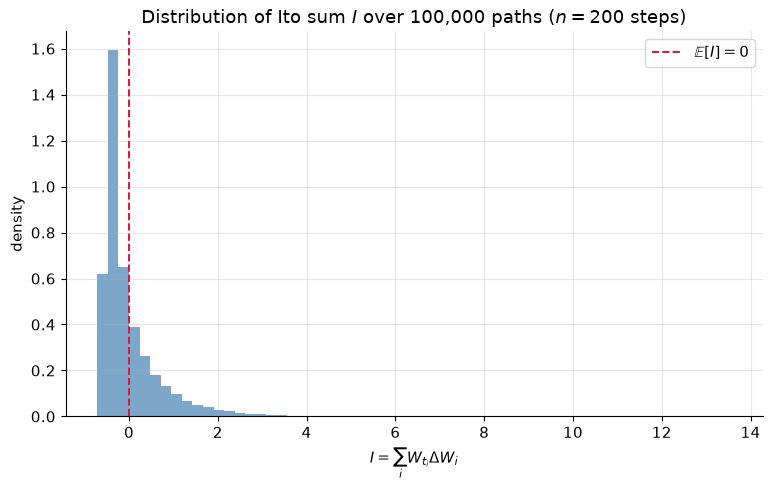

In [3]:
# Demo 2: Ito isometry — MC estimate of E[I^2] vs T^2/2, I = sum W_{t_i} dW_i over n=200 steps
T2 = 1.0
n_steps2 = 200
n_paths2 = 100_000
dt2 = T2 / n_steps2

increments2 = rng.standard_normal((n_paths2, n_steps2)) * np.sqrt(dt2)
W_paths2 = np.concatenate([np.zeros((n_paths2, 1)), np.cumsum(increments2, axis=1)], axis=1)

W_left2 = W_paths2[:, :-1]
dW2 = np.diff(W_paths2, axis=1)
I_samples = np.sum(W_left2 * dW2, axis=1)

I2_samples = I_samples**2
mean_I2_hat = I2_samples.mean()
se_I2 = I2_samples.std(ddof=1) / np.sqrt(n_paths2)
target_isometry = T2**2 / 2

print(f"E[I]      hat = {I_samples.mean():.6f}  (target 0, martingale)")
print(f"E[I^2]    hat = {mean_I2_hat:.6f}, 3*SE = {3*se_I2:.6f}  (target T^2/2 = {target_isometry:.6f})")

fig, ax = plt.subplots()
ax.hist(I_samples, bins=60, density=True, color="steelblue", alpha=0.7)
ax.axvline(0.0, color="crimson", linestyle="--", linewidth=1.4, label=r"$\mathbb{E}[I]=0$")
ax.set_xlabel(r"$I=\sum_i W_{t_i}\Delta W_i$")
ax.set_ylabel("density")
ax.set_title(f"Distribution of Ito sum $I$ over {n_paths2:,} paths ($n={n_steps2}$ steps)")
ax.legend()
plt.show()

La media muestral de $I$ es prácticamente $0$ — consistente con la martingalidad demostrada en §2.2 ($\mathbb{E}[I_T]=I_0=0$). El segundo momento $\widehat{\mathbb{E}}[I^2]$ cae dentro de $3$ SE del valor teórico de la isometría $T^2/2=0.5$: la varianza de la integral de Itô coincide con la energía $L^2$ del integrando $\int_0^T\mathbb{E}[W_t^2]\,dt$, exactamente como predice la Proposición de §2.1 (aquí verificada en el caso de partición fina, no en el límite continuo exacto, pero $n=200$ pasos ya es suficientemente fino para que el error de discretización sea despreciable frente al error de Monte Carlo).

### Demo 3 — Verificación de la deriva de Itô: $\mathbb{E}[\ln S_T]$ vía Euler-Maruyama vs $\ln S_0+(\mu-\sigma^2/2)T$

Simulamos $n_{\text{paths}}=100\,000$ trayectorias de GBM ($dS_t=\mu S_t\,dt+\sigma S_t\,dW_t$) por discretización de **Euler-Maruyama** ($n=250$ pasos, no la solución exacta — así la comparación es una verificación numérica independiente, no una tautología) y comparamos la media muestral de $\ln S_T$ contra la fórmula del Ejemplo 2 (§3.3), $\ln S_0+(\mu-\sigma^2/2)T$, derivada del lema de Itô aplicado a $f(x)=\ln x$. Euler-Maruyama se estudia con detalle (incluida su tasa de convergencia) en 01.4; aquí solo lo usamos como generador independiente de trayectorias.

E[ln S_T] hat = 4.654564, 3*SE = 0.002369  (target ln(S0)+(mu-sigma^2/2)T = 4.653920)
Naive target ln(S0)+mu*T = 4.685170  (off by sigma^2/2*T = 0.031250)


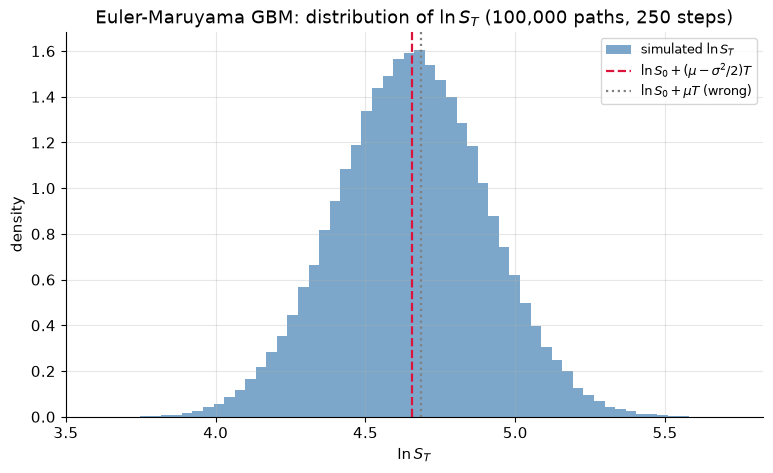

In [4]:
# Demo 3: Euler-Maruyama GBM simulation -> E[ln S_T] vs Ito-lemma drift formula
S0 = 100.0
mu = 0.08
sigma = 0.25
T3 = 1.0
n_steps3 = 250
n_paths3 = 100_000
dt3 = T3 / n_steps3

S = np.full(n_paths3, S0)
for _ in range(n_steps3):
    Z = rng.standard_normal(n_paths3)
    S = S + mu * S * dt3 + sigma * S * np.sqrt(dt3) * Z

assert np.all(S > 0), "Euler-Maruyama produced non-positive S_T (step too coarse)"

lnS_T = np.log(S)
mean_lnST_hat = lnS_T.mean()
se_lnST = lnS_T.std(ddof=1) / np.sqrt(n_paths3)
target_drift = np.log(S0) + (mu - sigma**2 / 2) * T3

print(f"E[ln S_T] hat = {mean_lnST_hat:.6f}, 3*SE = {3*se_lnST:.6f}  (target ln(S0)+(mu-sigma^2/2)T = {target_drift:.6f})")

# Naive (wrong) comparison: mistaking the drift for mu instead of mu - sigma^2/2
naive_target = np.log(S0) + mu * T3
print(f"Naive target ln(S0)+mu*T = {naive_target:.6f}  (off by sigma^2/2*T = {sigma**2/2*T3:.6f})")

fig, ax = plt.subplots()
ax.hist(lnS_T, bins=60, density=True, color="steelblue", alpha=0.7, label=r"simulated $\ln S_T$")
ax.axvline(target_drift, color="crimson", linestyle="--", linewidth=1.6, label=r"$\ln S_0+(\mu-\sigma^2/2)T$")
ax.axvline(naive_target, color="gray", linestyle=":", linewidth=1.6, label=r"$\ln S_0+\mu T$ (wrong)")
ax.set_xlabel(r"$\ln S_T$")
ax.set_ylabel("density")
ax.set_title(f"Euler-Maruyama GBM: distribution of $\\ln S_T$ ({n_paths3:,} paths, {n_steps3} steps)")
ax.legend(fontsize=9)
plt.show()

La media simulada de $\ln S_T$ (vía Euler-Maruyama, sin usar en ningún momento la solución exacta) cae dentro de $3$ SE de $\ln S_0+(\mu-\sigma^2/2)T$ — la fórmula derivada del lema de Itô en el Ejemplo 2. La línea gris punteada, $\ln S_0+\mu T$, marca el error que cometería alguien que ignorara la corrección de Itô $-\sigma^2T/2$ (confundiendo la tasa de crecimiento logarítmico con la tasa de crecimiento aritmético $\mu$): con $\sigma=0.25$ y $T=1$, ese error es $\sigma^2/2=0.03125$ en unidades de log-precio, muchas veces el error estándar de la simulación — la diferencia es real, no ruido numérico, y es exactamente la que separa $\mathbb{E}[S_T]=S_0e^{\mu T}$ de $\mathbb{E}[\ln S_T]\neq\ln\mathbb{E}[S_T]$ por la desigualdad de Jensen (la exponencial es convexa).

## 5. Validación

Verificamos formalmente tres resultados derivados arriba:

1. **Isometría de Itô (demo 2):** $\widehat{\mathbb{E}}[I^2]$ debe caer dentro de $3$ errores estándar (SE) de $T^2/2$.
2. **Deriva de Itô (demo 3):** $\widehat{\mathbb{E}}[\ln S_T]$ debe caer dentro de $3$ SE de $\ln S_0+(\mu-\sigma^2/2)T$.
3. **Convergencia de las sumas de Itô y Stratonovich en la partición más fina (demo 1):** la suma de Itô debe coincidir *exactamente* (a precisión de máquina) con $(W_T^2-Q_n)/2$ — identidad algebraica, no aproximación — y ambas sumas deben caer dentro de una tolerancia explícita, derivada de las cotas de varianza de §1.2 y §2.3 de 01.2, de sus límites teóricos $(W_T^2-T)/2$ y $W_T^2/2$.

In [5]:
# Validation 1: Ito isometry within 3 SE of T^2/2
print(f"[Isometry] |E[I^2]_hat - T^2/2| = {abs(mean_I2_hat - target_isometry):.6f}, 3*SE = {3*se_I2:.6f}")
assert abs(mean_I2_hat - target_isometry) <= 3 * se_I2, "Ito isometry MC estimate outside 3 SE of T^2/2"

# Validation 2: Ito drift within 3 SE of ln(S0) + (mu - sigma^2/2)*T
print(f"[Ito drift] |E[ln S_T]_hat - target| = {abs(mean_lnST_hat - target_drift):.6f}, 3*SE = {3*se_lnST:.6f}")
assert abs(mean_lnST_hat - target_drift) <= 3 * se_lnST, "Euler-Maruyama E[ln S_T] outside 3 SE of Ito-lemma drift formula"

# Validation 3a: exact algebraic identity, Ito sum == (W_T^2 - Q_n)/2, at the finest partition
identity_lhs = ito_sums[-1]
identity_rhs = (W_T**2 - qv_values[-1]) / 2
print(f"[Identity]  Ito sum = {identity_lhs:.10f}, (W_T^2-Q_n)/2 = {identity_rhs:.10f}")
assert np.isclose(identity_lhs, identity_rhs, atol=1e-9), "Ito sum != (W_T^2-Q_n)/2 to floating-point precision"

# Validation 3b: convergence of both sums at the finest partition, within explicit theoretical tolerances
n_finest = n_values[-1]
mesh_finest = T / n_finest

# Ito sum: error is exactly (T - Q_n)/2; bound |T-Q_n| via Var(Q_n) <= 2*T*mesh (01.2 Sec 2.3), 3-SE margin
se_Qn = np.sqrt(2 * T * mesh_finest)
tol_ito = 3 * se_Qn / 2
err_ito = abs(ito_sums[-1] - ito_target)
print(f"[Ito conv.] |Ito sum - (W_T^2-T)/2| = {err_ito:.6f}, tolerance (3*SE(Q_n)/2) = {tol_ito:.6f}")
assert err_ito <= tol_ito, "Ito sum at finest partition outside tolerance of (W_T^2-T)/2"

# Stratonovich sum: residual = (T-Q_n)/2 + (sum a_i^2 - T/2) + sum a_i*b_i
# SE(sum a_i^2) = T/sqrt(2n), SE(sum a_i*b_i) = T/(2*sqrt(n)) (derived in Sec. 1.2); combine with 5x margin (single path)
se_a2 = T / np.sqrt(2 * n_finest)
se_ab = T / (2 * np.sqrt(n_finest))
tol_strat = 5 * (se_Qn / 2 + se_a2 + se_ab)
err_strat = abs(strat_sums[-1] - strat_target)
print(f"[Strat conv.] |Strat sum - W_T^2/2| = {err_strat:.6f}, tolerance (5x combined SE) = {tol_strat:.6f}")
assert err_strat <= tol_strat, "Stratonovich sum at finest partition outside tolerance of W_T^2/2"

print("Validation passed: isometry and Ito drift within 3 SE; Ito sum matches (W_T^2-Q_n)/2 exactly; "
      "both sums converge within explicit theoretical tolerances at the finest partition.")

[Isometry] |E[I^2]_hat - T^2/2| = 0.004012, 3*SE = 0.018174
[Ito drift] |E[ln S_T]_hat - target| = 0.000644, 3*SE = 0.002369
[Identity]  Ito sum = -0.4330990115, (W_T^2-Q_n)/2 = -0.4330990115
[Ito conv.] |Ito sum - (W_T^2-T)/2| = 0.004441, tolerance (3*SE(Q_n)/2) = 0.016573
[Strat conv.] |Strat sum - W_T^2/2| = 0.000185, tolerance (5x combined SE) = 0.074774
Validation passed: isometry and Ito drift within 3 SE; Ito sum matches (W_T^2-Q_n)/2 exactly; both sums converge within explicit theoretical tolerances at the finest partition.


## Referencias

- Shreve, S. (2004). *Stochastic Calculus for Finance II: Continuous-Time Models*, cap. 4.
- Øksendal, B. (2003). *Stochastic Differential Equations: An Introduction with Applications*, 6th ed. Springer, cap. 3–4.